This is the presentation of creating the number classifying from start to end with visualization

Shape of data (60000, 28, 28)
Shape of target (60000,)


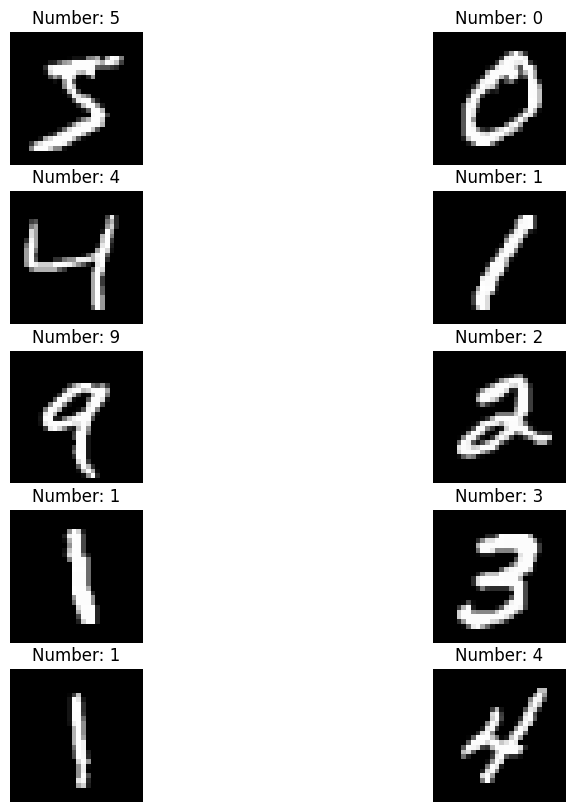

In [19]:
import numpy as np 
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers # type: ignore

# Load data into variable
data = np.load("data/mnist.npz") 

# Extract train, test, file
x_train, x_test, y_train, y_test = data["x_train"], data["x_test"], data["y_train"], data["y_test"]

# Convert integer labels to one-hot vectors for better loss function
y_train_onehot = keras.utils.to_categorical(y_train, num_classes=10)
y_test_onehot = keras.utils.to_categorical(y_test, num_classes=10)

print("Shape of data", x_train.shape)
print("Shape of target", y_train.shape)

#Draw first 10 number in train to see
plt.figure(figsize=(10,10)) #width 10, height 10
for i in range(10):
    plt.subplot(5, 2, i + 1)
    plt.imshow(x_train[i], cmap="gray")  # change cmap if RGB
    plt.title(f"Number: {y_train[i]}")
    plt.axis("off")
plt.show()

Then next, we will define the layer of the model and the compile of the model

In [23]:


# Creating my model
model = keras.Sequential([
    layers.Flatten(input_shape=(28, 28)),   # will turn (28,28) into (784,)

    layers.Dense(32, activation = "sigmoid"), #taking in input,first layer
    layers.Dropout(0.4),

    layers.Dense(16, activation = "relu" ), # second layer
    
    layers.Dense(16, activation = "relu" ), # third layer
    layers.Dropout(0.2),

    layers.Dense(10, activation = "softmax") #Result as probabilities of final results
])

#defining optimizer, in this case adam ~ gradient descent
#loss will be mean absolute error
model.compile(
    optimizer = "adam",
    loss ="mean_squared_error",
    metrics=["accuracy"]
)

Next, we will fit the data into the model for it to training,

In [24]:
history = model.fit(
    x_train, y_train_onehot, # testing data
    validation_data =(x_test, y_test_onehot),
    batch_size = 32, # after 32 sample, the optimizer will change the weights
    epochs = 10,
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.4198 - loss: 0.0691 - val_accuracy: 0.7369 - val_loss: 0.0396
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6071 - loss: 0.0520 - val_accuracy: 0.7954 - val_loss: 0.0324
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6517 - loss: 0.0480 - val_accuracy: 0.7859 - val_loss: 0.0317
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6870 - loss: 0.0438 - val_accuracy: 0.8468 - val_loss: 0.0245
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.7096 - loss: 0.0412 - val_accuracy: 0.8423 - val_loss: 0.0238
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7338 - loss: 0.0387 - val_accuracy: 0.8592 - val_loss: 0.0215
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7441 - loss: 0.0375 - val_accuracy: 0.8555 - val_loss: 0.0216
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7532 - loss: 0.0369 - 

A better way to view the loss though is to plot it. The fit method in fact keeps a record of the loss produced during training in a History object. We'll convert the data to a Pandas dataframe, which makes the plotting easy.

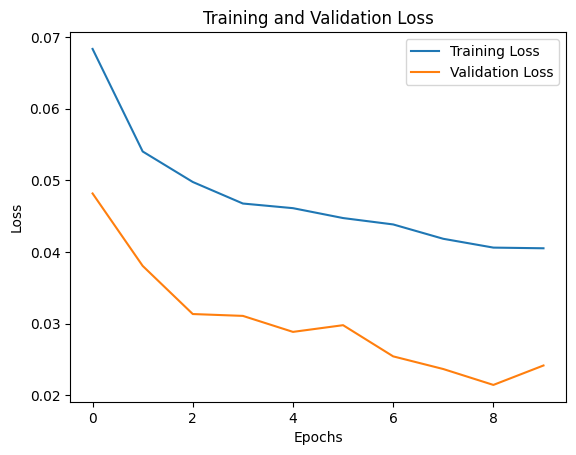

In [22]:
import pandas as pd
# convert the training history to a dataframe
history_df = pd.DataFrame(history.history)
# use Pandas native plot method
plt.plot(history_df['loss'], label='Training Loss')
plt.plot(history_df['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

Checking the accuracy of the model on test data:

In [25]:
loss, accuracy = model.evaluate(x_test, y_test_onehot, verbose=0)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Test Loss: 0.0202
Test Accuracy: 0.8647
